

ok so. most of us are packed between 0.68 and 0.70 (i'm #17 at 0.6782, so this is self-therapy too). different architectures, different losses, everyone lands in the same place. instead of training model #12, i decided to ask a weirder question:

> **what would an ORACLE score on this metric?**

take the ground truth itself, handicap it in controlled ways (flatten it, take its median, blur it...), and score these "cheating predictors" with the exact competition metric. no model anywhere in this notebook — just the data and the metric. the answer explains the plateau, and (spoiler) the top ~16 have already escaped it, in a very specific direction.

everything below runs on the **full 40,686-tile training set** with the exact metric. runs end-to-end in a few minutes. 


In [ ]:
import os, ast, glob, json
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# ---- find the data  ----
#########

# ---- THE metric: per-sample RMSE (per tile sqrt(mean(sq err)), then plain mean over tiles) ----
def tile_rmse(pred, y):
    return float(np.sqrt(((pred - y) ** 2).mean()))

# small plot style so figures don't look like default matplotlib
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, VIOLET, RED, SURF = "#2a78d6", "#4a3aa7", "#e34948", "#fcfcfb"
RAIN = LinearSegmentedColormap.from_list("rain", [SURF,"#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#1c5cab","#104281","#0d366b"])
plt.rcParams.update({"figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "sans-serif", "text.color": INK, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False})

train rows: 40686  |  locations: 20


## one pass over every target

single streaming pass over all 40,686 GPM tiles. for each tile i keep its mean, mean-square, and directly score the per-tile oracles (median / mean+mask need the raw pixels). the flat-constant + climatology + oracle-mean scores then come out of the stored stats for free — `rmse(c) = sqrt(c² − 2c·mean + meansq)` per tile, and the flat tile-mean oracle is just each tile's pixel std.

In [2]:
N = len(df)
t_mean  = np.zeros(N); t_msq = np.zeros(N); t_y2 = np.zeros(N)
r_med   = np.zeros(N); r_mask = np.zeros(N)
zero_px = 0; tot_px = 0
THR = np.array([0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 40]); y2_ge = np.zeros(len(THR))
locs = df.name_location.values

for i, fn in enumerate(df.gpm_imerg_filename.values):
    y = tifffile.imread(os.path.join(TRAIN, "gpm_imerg", fn)).astype(np.float32)
    y = np.clip(np.nan_to_num(y), 0, None)
    t_mean[i], t_msq[i] = y.mean(), (y * y).mean()
    t_y2[i] = (y * y).sum()
    r_med[i]  = tile_rmse(np.full_like(y, np.median(y)), y)
    wet = y > 0
    r_mask[i] = tile_rmse(np.where(wet, y[wet].mean() if wet.any() else 0.0, 0.0), y)
    zero_px += int((y == 0).sum()); tot_px += y.size
    for k, t in enumerate(THR): y2_ge[k] += (y[y >= t] ** 2).sum()
    if i % 10000 == 0: print(f"  {i}/{N}")

rmse_const = lambda c: np.sqrt(np.maximum(c*c - 2*c*t_mean + t_msq, 0)).mean()
loc_mean = {L: t_mean[locs == L].mean() for L in np.unique(locs)}
ladder = {
  "predict zero":              rmse_const(0.0),
  "global mean const":         rmse_const(t_mean.mean()),
  "per-location climatology":  float(np.mean([np.sqrt(max(loc_mean[L]**2 - 2*loc_mean[L]*m + q, 0))
                                              for L, m, q in zip(locs, t_mean, t_msq)])),
  "ORACLE tile median (flat)": float(r_med.mean()),
  "ORACLE tile mean (flat)":   float(np.sqrt(np.maximum(t_msq - t_mean**2, 0)).mean()),
  "ORACLE mean + wet mask":    float(r_mask.mean()),
}
best_c = min(np.linspace(0, 1, 101), key=rmse_const)
print(json.dumps({k: round(v, 4) for k, v in ladder.items()}, indent=1))
print(f"best flat constant: {best_c}  |  exact-zero pixels: {zero_px/tot_px:.2%}")

  0/40686


  10000/40686


  20000/40686


  30000/40686


  40000/40686


{
 "predict zero": 0.746,
 "global mean const": 0.8435,
 "per-location climatology": 0.7979,
 "ORACLE tile median (flat)": 0.718,
 "ORACLE tile mean (flat)": 0.6766,
 "ORACLE mean + wet mask": 0.5939
}
best flat constant: 0.0  |  exact-zero pixels: 82.07%


## read that table again, slowly

- **best flat constant is exactly 0.** any uniform drizzle loses to silence. (predict-zero = **0.746** — if your score is above this, submit zeros first, seriously.)
- **per-location climatology loses to zero** (0.798!) — and that's *in-sample*. test locations are disjoint, so location-identity features are a trap, not a feature.
- even an **oracle median** (0.718) loses to the **oracle mean** (0.677) by 0.041. the metric is RMSE: serve the conditional MEAN. never a median, never "a typical value". we learned this one with cash (a quantile head served at q0.5 cost us ~0.006 LB).
- and the headline: a model that predicts every tile's **true average rain PERFECTLY** — zero error on the amount, something no real model will ever do — scores **0.677**.

that number is the wall. now look where the leaderboard sits.

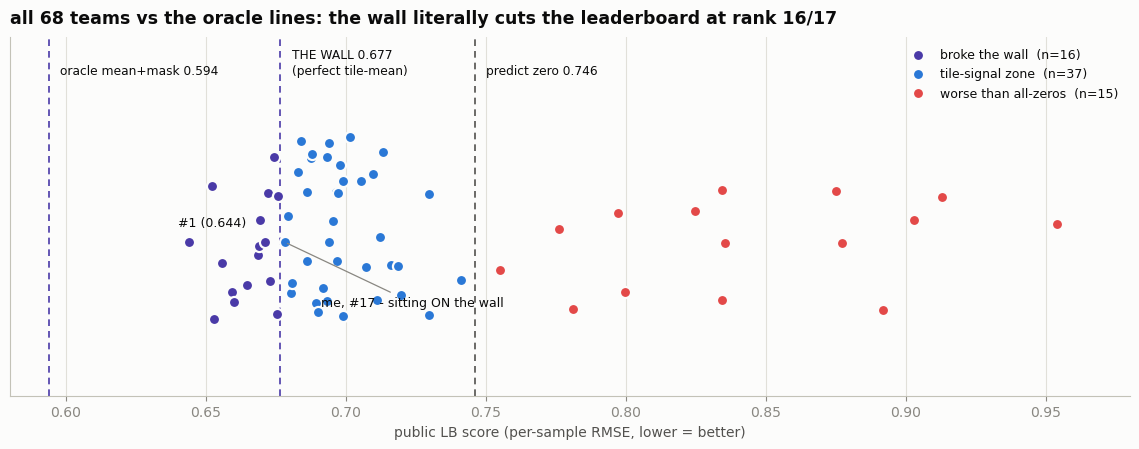

teams below the wall: 16 | teams scoring worse than predicting all zeros: 15


In [3]:
# public LB, all 68 scored teams (as of jul 2)
LB = [0.6441,0.6520,0.6527,0.6557,0.6593,0.6599,0.6648,0.6684,0.6690,0.6692,0.6711,0.6720,0.6728,
      0.6744,0.6755,0.6757,0.6782,0.6794,0.6805,0.6806,0.6828,0.6838,0.6860,0.6862,0.6876,0.6879,
      0.6893,0.6900,0.6918,0.6932,0.6932,0.6940,0.6941,0.6955,0.6966,0.6969,0.6970,0.6979,0.6988,
      0.6989,0.7014,0.7055,0.7071,0.7098,0.7111,0.7121,0.7131,0.7159,0.7186,0.7196,0.7297,0.7297,
      0.7410,0.7549,0.7759,0.7811,0.7970,0.7995,0.8246,0.8342,0.8342,0.8353,0.8751,0.8770,0.8918,
      0.9028,0.9127,0.9540]
WALL, MASK, ZERO = ladder["ORACLE tile mean (flat)"], ladder["ORACLE mean + wet mask"], ladder["predict zero"]

fig, ax = plt.subplots(figsize=(11.5, 4.6))
rng = np.random.RandomState(1); jit = rng.uniform(-0.30, 0.30, len(LB))
for zone, (lo, hi), c in [("broke the wall", (0, WALL), VIOLET),
                          ("tile-signal zone", (WALL, ZERO), BLUE),
                          ("worse than all-zeros", (ZERO, 2), RED)]:
    m = [(lo <= s < hi) for s in LB]
    ax.scatter(np.array(LB)[m], jit[m], s=64, c=c, edgecolors=SURF, linewidths=1.6, zorder=3,
               label=f"{zone}  (n={sum(m)})")
for x, lab, c in [(MASK, f"oracle mean+mask {MASK:.3f}", VIOLET), (WALL, f"THE WALL {WALL:.3f}\n(perfect tile-mean)", VIOLET),
                  (ZERO, f"predict zero {ZERO:.3f}", INK2)]:
    ax.axvline(x, color=c, lw=1.2, ls=(0,(4,3)), zorder=1)
    ax.text(x + 0.004, 0.50, lab, ha="left", fontsize=8.8, color=INK, linespacing=1.25)
ax.annotate("#1 (0.644)", (LB[0], jit[0]), textcoords="offset points", xytext=(-8, 12), fontsize=9, color=INK)
ax.annotate("me, #17 - sitting ON the wall", (0.6782, jit[16]), textcoords="offset points",
            xytext=(26, -46), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.9))
ax.set_yticks([]); ax.set_xlim(0.58, 0.98); ax.set_ylim(-0.55, 0.62)
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_xlabel("public LB score (per-sample RMSE, lower = better)")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title("all 68 teams vs the oracle lines: the wall literally cuts the leaderboard at rank 16/17",
             fontsize=12.5, fontweight="bold", loc="left", color=INK, pad=10)
plt.tight_layout(); plt.show()
n_broke = sum(s < WALL for s in LB); n_worse0 = sum(s > ZERO for s in LB)
print(f"teams below the wall: {n_broke} | teams scoring worse than predicting all zeros: {n_worse0}")

three zones, one line each:

- **16 teams have broken the wall.** they are getting information a perfect tile-average forecaster *cannot have* — i.e. they know smth about **where the rain sits inside the 41×41 tile**, not just how much.
- **the 0.68–0.75 pack (me included)** is at or above the wall: we've squeezed out the tile-level signal and are now competing over rounding errors of the same quantity. more seeds/ensembles of "how-much" models cannot pass 0.677, even in the limit of perfection. that's why the plateau feels like a wall — it *is* one.
- **15 teams score worse than predicting literal zeros.** if that's you: submit all-zeros once (0.746), then fix drizzle — you're leaking small positive values over the 82% dry pixels.

and the next rung is huge: perfect tile-mean **+ perfect wet/dry mask** scores **0.594**. that's 0.083 of headroom in pure *localization* — ~2.5× the entire gap between #1 and the pack. (fwiw a σ=2px *blurred* truth still scores ~0.38 — you don't need sharp peaks, you need correctly-PLACED rain.)

## where the error actually lives

82% of pixels are exact zeros, so people assume the score is about dry pixels. it isn't — the metric averages *per-tile* RMSE, and wet tiles have huge RMSE:

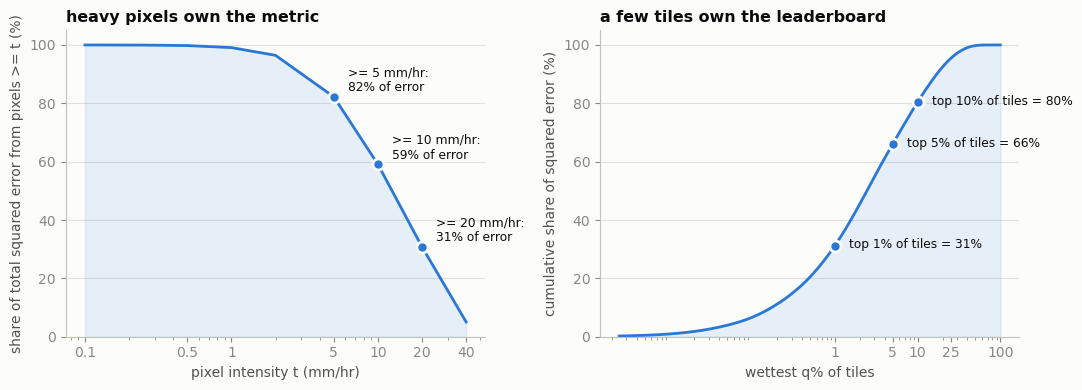

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
tot = t_y2.sum()
share = [s/tot*100 for s in y2_ge]
a1.plot(THR, share, color=BLUE, lw=2, zorder=3); a1.fill_between(THR, 0, share, color=BLUE, alpha=0.10)
for t, s in zip(THR, share):
    if t in (5, 10, 20):
        a1.plot(t, s, "o", ms=8, color=BLUE, mec=SURF, mew=2, zorder=4)
        a1.annotate(f">= {t:g} mm/hr:\n{s:.0f}% of error", (t, s), textcoords="offset points", xytext=(10, 4), fontsize=8.8)
a1.set_xscale("log"); a1.set_xticks([0.1,0.5,1,5,10,20,40]); a1.set_xticklabels(["0.1","0.5","1","5","10","20","40"])
a1.set_xlabel("pixel intensity t (mm/hr)"); a1.set_ylabel("share of total squared error from pixels >= t (%)")
a1.set_title("heavy pixels own the metric", fontsize=11.5, fontweight="bold", loc="left")
srt = np.sort(t_y2)[::-1]; cum = np.cumsum(srt)/tot*100; q = np.arange(1, N+1)/N*100
a2.plot(q, cum, color=BLUE, lw=2); a2.fill_between(q, 0, cum, color=BLUE, alpha=0.10)
for pct in (1, 5, 10):
    v = cum[int(N*pct/100)-1]
    a2.plot(pct, v, "o", ms=8, color=BLUE, mec=SURF, mew=2)
    a2.annotate(f"top {pct}% of tiles = {v:.0f}%", (pct, v), textcoords="offset points", xytext=(10, -2), fontsize=8.8)
a2.set_xscale("log"); a2.set_xticks([1,5,10,25,100]); a2.set_xticklabels(["1","5","10","25","100"])
a2.set_xlabel("wettest q% of tiles"); a2.set_ylabel("cumulative share of squared error (%)")
a2.set_title("a few tiles own the leaderboard", fontsize=11.5, fontweight="bold", loc="left")
for a in (a1, a2): a.grid(axis="y", color=GRID, lw=0.8); a.set_axisbelow(True); a.set_ylim(0, 105)
plt.tight_layout(); plt.show()

so ~1% of pixels (the ≥5 mm/hr ones) carry ~82% of the squared error, and the wettest 5% of tiles carry ~66% of the whole score.

**tempting-but-wrong conclusion:** "just up-weight heavy rain in the loss." we measured it — net negative on LB. the up-weighted model buys a little accuracy on rare wet tiles and pays with drizzle leaked across the 82% zeros, and the metric taxes that hard (remember: best constant is 0). what actually helped for free: **zero out predictions below ~0.1 mm/hr**. both things are true at once: the score lives in wet tiles, *and* you must keep dry pixels at exactly 0. the only way to win both is better *structure*, not re-weighting.

## what the wall looks like, up close

four real training tiles vs the *cheating* flat tile-mean (per-column shared color scale):

/var/folders/x8/v2y9hgbj25z8__5d154k2m6m0000gn/T/ipykernel_93415/680102799.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, .95)); plt.show()


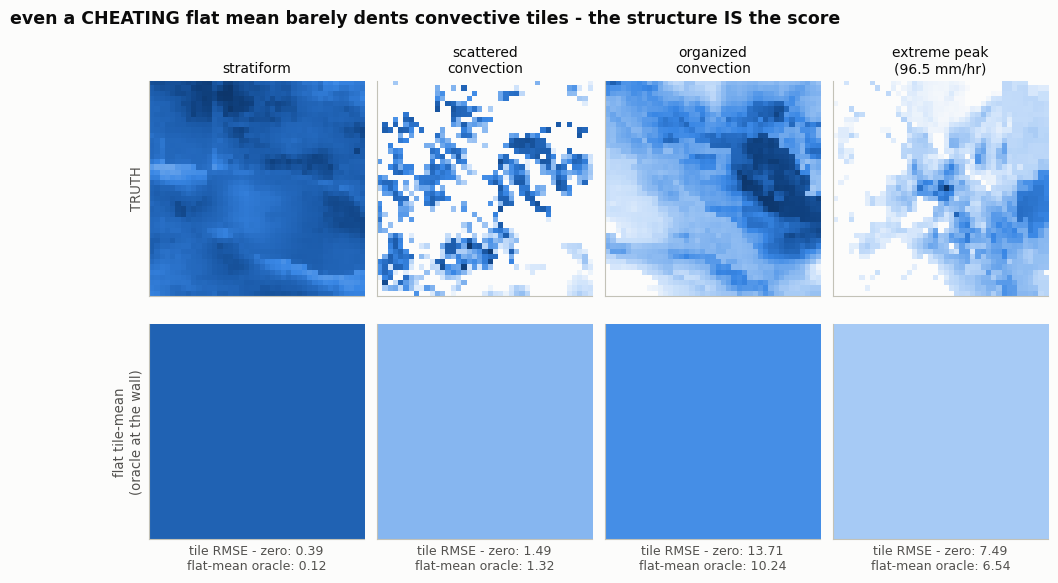

In [5]:
PICKS = [("train_jakarta_GPM_IMERG_2023-01-01_00-00-00.tif", "stratiform"), ("train_guangdong_GPM_IMERG_2023-01-10_19-00-00.tif", "scattered\nconvection"),
         ("train_aceh_GPM_IMERG_2025-11-25_16-30-00.tif", "organized\nconvection"), ("train_central_vietnam_GPM_IMERG_2025-11-02_06-30-00.tif", "extreme peak\n(96.5 mm/hr)")]
fig, axes = plt.subplots(2, 4, figsize=(11.6, 6.2), gridspec_kw={"wspace": .06, "hspace": .04})
for j, (fn, name) in enumerate(PICKS):
    y = np.clip(np.nan_to_num(tifffile.imread(os.path.join(TRAIN, "gpm_imerg", fn)).astype(np.float32)), 0, None)
    flat = np.full_like(y, y.mean()); vmax = max(y.max(), .5)
    for i, arr in enumerate([y, flat]):
        ax = axes[i, j]; ax.imshow(arr, cmap=RAIN, norm=PowerNorm(.45, vmin=0, vmax=vmax), aspect="equal")
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0: ax.set_ylabel(["TRUTH", "flat tile-mean\n(oracle at the wall)"][i], fontsize=9.5, color=INK2)
    axes[0, j].set_title(name, fontsize=10)
    axes[1, j].set_xlabel(f"tile RMSE - zero: {tile_rmse(0*y, y):.2f}\nflat-mean oracle: {tile_rmse(flat, y):.2f}",
                          fontsize=9, color=INK2)
plt.suptitle("even a CHEATING flat mean barely dents convective tiles - the structure IS the score",
             fontsize=12.5, fontweight="bold", x=.005, ha="left")
plt.tight_layout(rect=(0, 0, 1, .95)); plt.show()

the flat mean nearly solves stratiform rain (0.39 → 0.12) but keeps ~75% of the error on the organized-convection tile (13.7 → 10.2). convective spatial structure isn't an edge case of this competition — it *is* the competition.

## bonus: don't waste a day on the `test_files/` "targets"

the GPM tifs inside the evaluation zip look like targets. they're not — they're noise placeholders. proof in 10 lines:

In [6]:
EVAL = sorted(glob.glob(os.path.join(os.path.dirname(TRAIN), "evaluation_dataset_*")))[0]
files = sorted(glob.glob(os.path.join(EVAL, "test_files", "*.tif")))[:50]
if files:
    vals = np.stack([tifffile.imread(f).astype(np.float32) for f in files])
    a = vals[0]; lag1 = np.corrcoef(a[:, :-1].ravel(), a[:, 1:].ravel())[0, 1]
    print(f"n={len(files)} files | mean={vals.mean():.4f} std={vals.std():.4f}  (Uniform[0,50] theory: 25.000, 14.434)")
    print(f"exact zeros: {(vals==0).mean():.1%}  (real GPM tiles: ~82%) | spatial lag-1 autocorr: {lag1:+.4f} (real rain: ~+0.9)")
    print("=> pure U[0,50] i.i.d. noise. placeholders, not a leak. move on :)")
else:
    print("test_files/ not present in this environment - see numbers in the text")

n=50 files | mean=24.9487 std=14.4263  (Uniform[0,50] theory: 25.000, 14.434)
exact zeros: 0.0%  (real GPM tiles: ~82%) | spatial lag-1 autocorr: +0.0012 (real rain: ~+0.9)
=> pure U[0,50] i.i.d. noise. placeholders, not a leak. move on :)


## takeaways (and the stuff i'd love to discuss)

1. **the leaderboard plateau at 0.68 is not a tuning problem — it's an information wall.** perfect tile-means score 0.677. everyone at/above it is competing over the same exhausted quantity.
2. **the game below the wall is within-tile localization.** the wet-mask rung alone is worth 0.083 — 2.5× the #1-to-pack gap. blurred-but-well-placed rain (0.38!) beats sharp-but-misplaced everything.
3. **serve the conditional mean.** oracle median loses by 0.041. quantile/median heads are structurally penalized here.
4. **best constant is 0; climatology < zero; location features are traps** (disjoint test locations).
5. **don't naive-tail-weight; do kill sub-0.1 drizzle.**

open questions for the thread — genuinely curious:
- for the sub-wall teams: is it displacement-tolerant losses? wet-mask aux heads? smth else entirely? (no need to give away your sauce — even "it's the loss" vs "it's the inputs" would be gold)
- has anyone made cloud-top **cooling rate** work as a localization signal? our hand-engineered versions didn't transfer into the CNN.
- with 20 train climates → 18 unseen test climates, big models overfit for us every single time. anyone winning WITH capacity?

credits: hengck23's malformed-files census (45 weird GOES tifs + 29 test rows with `[]` observations — go read that thread), crossentropy's EDA on the disjoint locations, Aman's band-wavelength table. this post just adds the measured layer on top. may your rain be well-placed 🌧️